In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
customer_df = pd.read_csv(
    "../data/processed/customer_support/customer_support_clean.csv"
)

retail_df = pd.read_csv(
    "../data/processed/online_retail/retail_clean.csv"
)

Customer Support Analysis
Analysis 1 — Ticket Volume by Type

In [3]:
customer_df["type"].value_counts()

type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

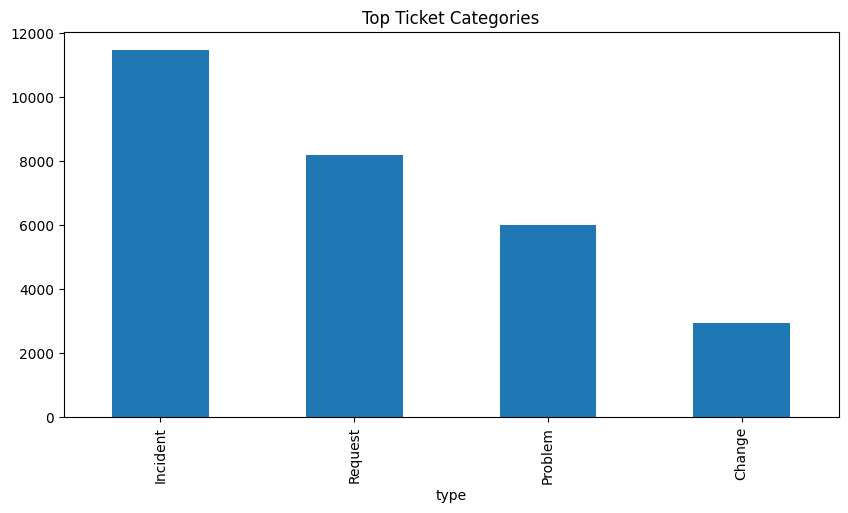

In [4]:
customer_df["type"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Ticket Categories")
plt.show()

Analysis 2 — Priority Distribution

In [5]:
customer_df["priority"].value_counts()

priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

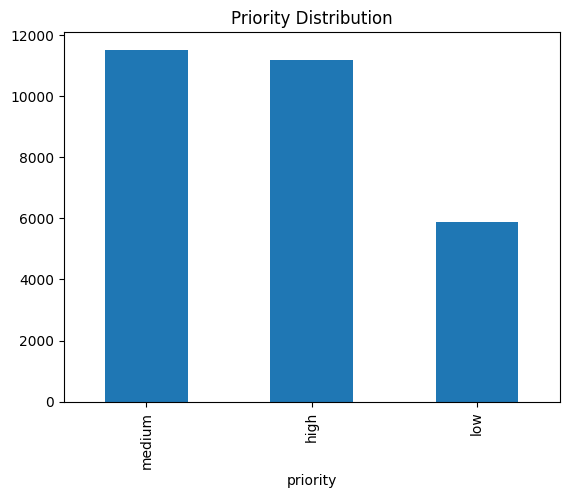

In [6]:
customer_df["priority"].value_counts().plot(
    kind="bar"
)

plt.title("Priority Distribution")
plt.show()

Analysis 3 — Queue Analysis

In [7]:
customer_df["queue"].value_counts()

queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

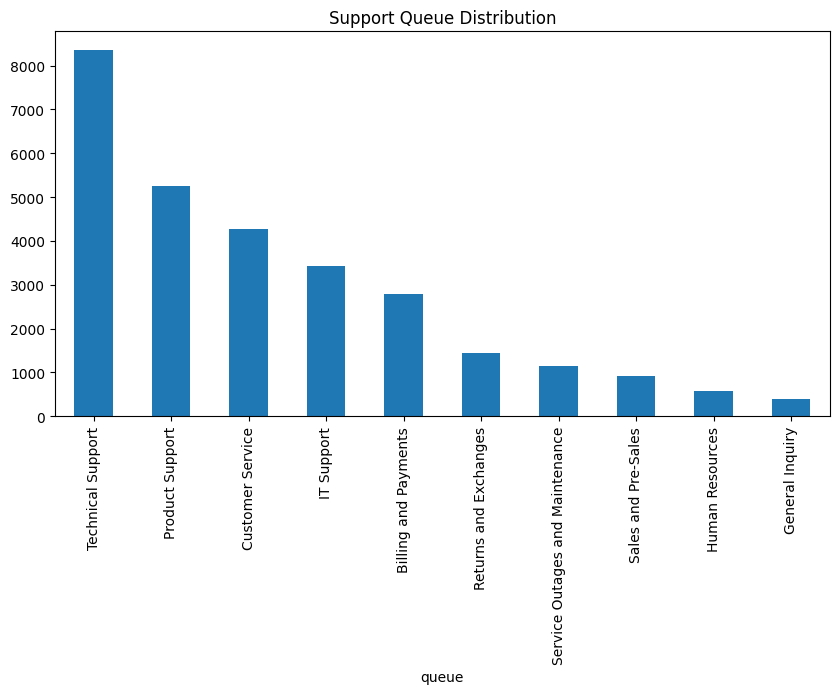

In [8]:
customer_df["queue"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Support Queue Distribution")
plt.show()

Analysis 4 — Language Distribution

In [9]:
customer_df["language"].value_counts()

language
en    16338
de    12249
Name: count, dtype: int64

Retail Analytics
Analysis 5 — Revenue Overview

In [10]:
retail_df["Revenue"] = (
    retail_df["Quantity"]
    *
    retail_df["UnitPrice"]
)

retail_df["Revenue"].describe()

count    540455.000000
mean         18.036188
std         379.318894
min     -168469.600000
25%           3.480000
50%           9.840000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

Analysis 6 — Revenue by Country

In [11]:
country_revenue = (
    retail_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

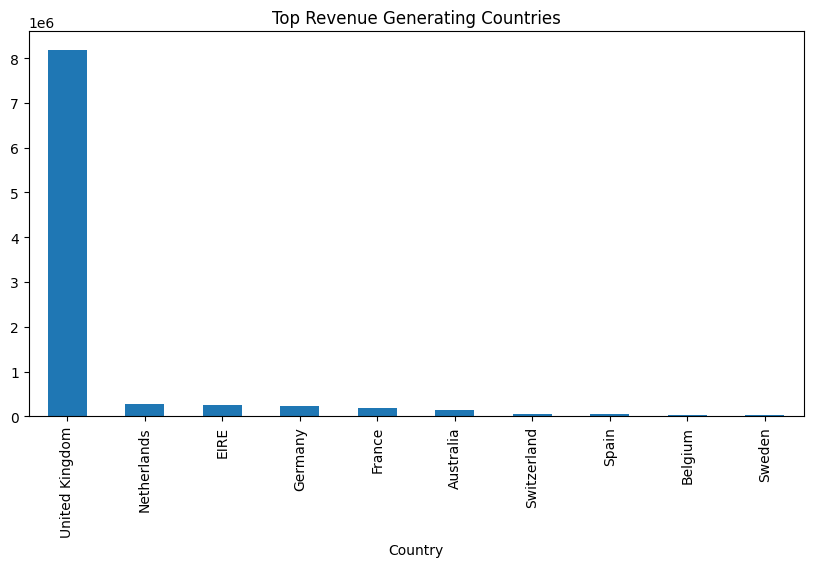

In [12]:
country_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Revenue Generating Countries")
plt.show()

Analysis 7 — Top Products

In [13]:
product_revenue = (
    retail_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

Analysis 8 — Monthly Revenue Trend

In [14]:
retail_df["InvoiceDate"] = pd.to_datetime(
    retail_df["InvoiceDate"]
)

retail_df["Month"] = (
    retail_df["InvoiceDate"]
    .dt.to_period("M")
)

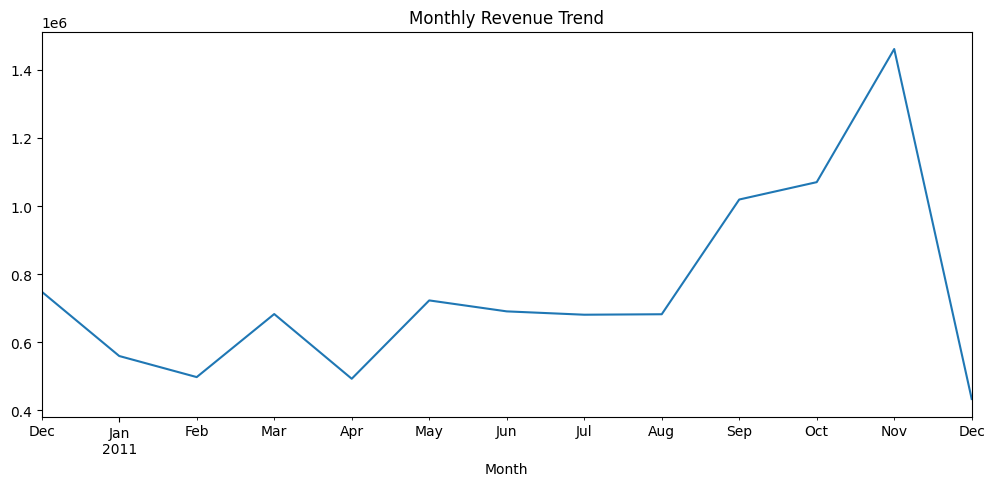

In [15]:
monthly_revenue = (
    retail_df.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue.plot(
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")
plt.show()